# A rising pile of unpaid invoices is supposed to be a red flag. Is it? 🧾
### Days Sales Outstanding — the receivables-vs-sales warning light from the forensic-accounting playbook — meets a liquid tape of big US companies

![Signal: None](https://img.shields.io/badge/Signal-None-c0392b?style=flat-square)
![Tradability: Mirage](https://img.shields.io/badge/Tradability-Mirage-c0392b?style=flat-square)
![Warns on sales%3F: Faint](https://img.shields.io/badge/Warns_on_sales%3F-Faint-8b949e?style=flat-square)

Here's a signal with real forensic-accounting logic behind it. When a company ships product but books the sale on credit, the money it's owed piles up as **accounts receivable**. Divide that pile by daily sales and you get **Days Sales Outstanding (DSO)** — how many days of revenue are stuck in unpaid invoices. When DSO *climbs* — receivables growing faster than sales — the textbooks get nervous: maybe the company is **channel-stuffing** (jamming product into the channel on soft credit terms to make the quarter), maybe it's booking revenue too aggressively, maybe customers just aren't paying. The pitch: rising DSO is tomorrow's bad news today — so **avoid (or short) the names whose DSO is building, and favour the ones keeping it lean.**

It's a famous fundamental signal (Abarbanell-Bushee). Does the warning light actually predict anything you can trade?

> 📓 **Plain-language layer.** Want the Newey-West *t*-stats, the placebo and the cost math? See **[02_for_the_quants.ipynb](02_for_the_quants.ipynb)**.
>
> ⚠️ **Method note.** ~38 large US filers with real trade receivables (EDGAR `AccountsReceivableNetCurrent` + `Revenues`), 2009→2026; a genuinely **thin, uneven panel**. House style in [METHODOLOGY.md](../../../METHODOLOGY.md).

In [1]:
import sys, os
sys.path.insert(0, os.path.abspath(".."))          # the study package
sys.path.insert(0, os.path.abspath("../../.."))    # repo root
%matplotlib inline
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
plt.rcParams.update({"figure.figsize": (9.5, 5.0), "axes.grid": True,
                     "grid.alpha": .3, "axes.spines.top": False, "axes.spines.right": False})
RED, AMBER, GREEN, GREY = "#c0392b", "#dab617", "#2ea44f", "#8b949e"

from dso_signal import data, strategy as st

HAVE_REAL = data.have_real()
if HAVE_REAL:
    PX, EV = data.load_real()
else:
    PX = EV = None
print("real cache present:", HAVE_REAL, "| events:", (0 if EV is None else len(EV)),
      "| names:", (0 if EV is None else EV['ticker'].nunique()))

# frozen headline numbers (mirror of docs/results.md)
R = {'as_of': '2026-06-30', 'n_names': 38, 'n_events': 1173, 'end_lo': '2009-07-31', 'end_hi': '2026-04-30', 'fp_prices': '83a4ccfa2027', 'n_months': 191, 'avg_n': 21.4, 'ls_span_lo': '2010-08-31', 'ls_span_hi': '2026-06-30', 'ls_mean_bps': 14.2, 'ls_ann': 1.71, 'ls_t_iid': 0.55, 'ls_t_nw': 0.53, 'ls_sharpe': 0.14, 'ls_hit': 52, 'ls_hit_lo': 45, 'ls_hit_hi': 59, 'ls_long_bps': 148.6, 'ls_short_bps': 134.3, 'ls_turn': 0.17, 'ls_cum': 1.16, 'ls120_mean_bps': 4.8, 'ls120_t_nw': 0.16, 'pct_mean_bps': 6.6, 'pct_t_nw': 0.27, 'pct_sharpe': 0.06, 'xsec_early': 27.3, 'xsec_late': 12.1, 'drift': {21: (1172, 1.31, 1.3, 0.01, 0.01, 50, 0.4927), 63: (1163, 4.43, 4.32, 0.11, 0.11, 51, 0.4363), 126: (1157, 8.1, 9.12, -1.01, -0.74, 50, 0.8123)}, 'mono63': (4.32, 3.55, 4.43), 'era_early_n': 89, 'era_early_bps': 29.8, 'era_early_t': 1.03, 'era_late_n': 102, 'era_late_bps': 0.7, 'era_late_t': 0.02, 'ws_n': 997, 'ws_slope': -0.0031, 'ws_t': -2.67, 'ws_r2': 0.007, 'ws_corr': -0.0843, 'ws_low_sales': 8.2, 'ws_high_sales': 4.9, 'ws_spread': 3.3, 'net': {(10, 50): (6.6, 0.79, 0.25, 0.06), (20, 100): (-1.0, -0.13, -0.04, -0.01)}, 'syn_null_mean': 0.01, 'syn_null_sd': 0.73, 'syn_null_fire': 0, 'syn_null_seeds': 12, 'syn_planted_bps': 860.8, 'syn_planted_t': 18.51}


real cache present: True | events: 1173 | names: 38


## The answer first

| Question | Answer |
|---|---|
| Does a building DSO predict **lower future returns**, as the red flag claims? | **No — not on this tape.** Long-lean / short-building earns a *right-signed but trivial* **+1.7%/yr** gross, robust *t* = **+0.53** (the bar is 2). More conservative versions of the signal are flat-zero, and the whole thing is **dead after 2018** (*t* = +0.02). |
| Does it at least **warn on future sales**? | **Faintly.** Lean-DSO names do grow next quarter's sales a bit faster than building-DSO names (+3.3 points), correctly signed — but the correlation is a whisker (**-0.08**). The mechanism is there in the sign, essentially absent in the magnitude. |
| Can you trade it? | **No.** It fails *before* costs, and after realistic costs + borrow it goes **negative** (-0.1%/yr). |
| Why so weak? | These are **big, liquid, heavily-covered** companies. A ratio anyone can compute from the 10-Q is the last place a durable edge survives — and here it didn't survive at all. |

> A famous forensic red flag that, on blue chips, lights up for neither the stock nor (much) the sales it's supposed to foretell.

## 1 · The claim

> *"When receivables grow faster than sales, Days Sales Outstanding rises. That's a red flag — channel-stuffing, aggressive revenue recognition, weak collections — and it precedes disappointment. Buy the lean-DSO names, short the building-DSO names."*

It's one of the nine fundamental signals in **Abarbanell & Bushee (1997/1998)**, a cousin of Sloan's accrual anomaly (a receivable *is* an accrual) and a term inside both the Piotroski F-score and the Beneish M-score. The receivables-vs-sales gap is as respectable as forensic red flags get.

## 2 · So what?

If one plain balance-sheet ratio flagged future losers, it would be one of the easiest anomalies going — no estimates feed, no alt-data, just receivables ÷ sales out of every 10-Q. That's exactly why it deserves suspicion: it's *too* readable. Everyone with a brokerage account can compute DSO. If markets price public accounting information at all, this is the kind they should price fastest.

## 3 · How would we even know?

- **The signal.** For each name, the year-over-year **change in DSO** (this quarter's DSO minus the same quarter a year ago), known only on the **filing date** of the 10-Q/10-K — never before the number is public.
- **The sales test.** Does a rising DSO this quarter precede *weaker* revenue growth next quarter? (The channel-stuffing mechanism.)
- **The return test.** Each month, rank the names on DSO change, buy the leanest third, short the building third, hold one month. Does the spread make money — and can we tell it apart from noise?
- **The mirage check.** If the return spread can't beat a coin-flip relabelling of the names, it's not a signal, however good the story sounds.

## 4 · The teardown — let's actually look

**First, the part the story leans on: does a building DSO warn on sales?** For every filing we line up this quarter's DSO change against *next* quarter's actual revenue growth, and split the names into a lean third and a building third.

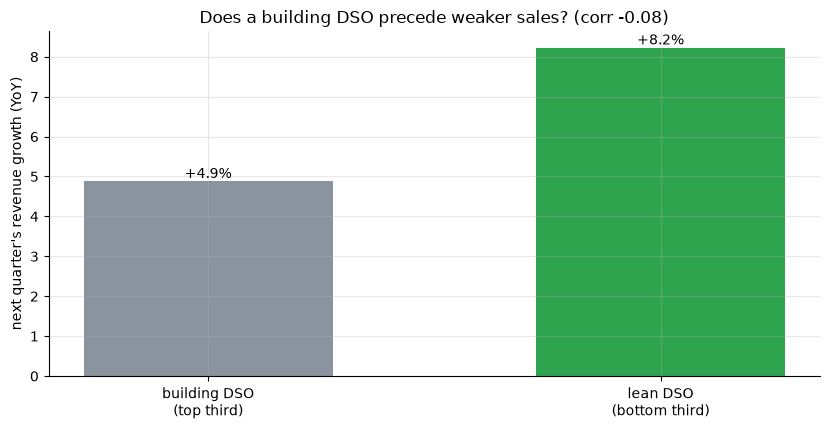

future sales growth: lean-DSO third +8.2% vs building-DSO third +4.9% -> spread +3.3 pp, correlation -0.08


In [2]:
if HAVE_REAL:
    q = st.warns_sales(EV)
    low, high, corr = q['low_sales']*100, q['high_sales']*100, q['corr']
else:
    low, high, corr = R['ws_low_sales'], R['ws_high_sales'], R['ws_corr']
fig, ax = plt.subplots(figsize=(8.4, 4.4))
ax.bar(['building DSO\n(top third)','lean DSO\n(bottom third)'],
       [high, low], color=[GREY, GREEN], width=.55)
for i,v in enumerate([high, low]): ax.annotate(f'{v:+.1f}%',(i,v),ha='center',va='bottom')
ax.set_ylabel("next quarter's revenue growth (YoY)")
ax.set_title(f'Does a building DSO precede weaker sales? (corr {corr:+.2f})')
plt.tight_layout(); plt.show()
print(f'future sales growth: lean-DSO third {low:+.1f}% vs building-DSO third {high:+.1f}% '
      f'-> spread {low-high:+.1f} pp, correlation {corr:+.2f}')

So there's a *nudge* in the right direction: lean-DSO names go on to grow next quarter's sales about **+3.3 points** faster than building-DSO names, and the correlation is negative as the red flag predicts. But look at how *small* it is — correlation **-0.08**, basically a flat scatter. The channel-stuffing mechanism exists in the *sign* and almost vanishes in the *magnitude*. Hold that thought — because it's the strongest thing in this whole study.

**Now the money question: do the stocks follow?** Same ranking, but instead of future sales we measure the forward *return* of a buy-the-lean-third, short-the-building-third portfolio.

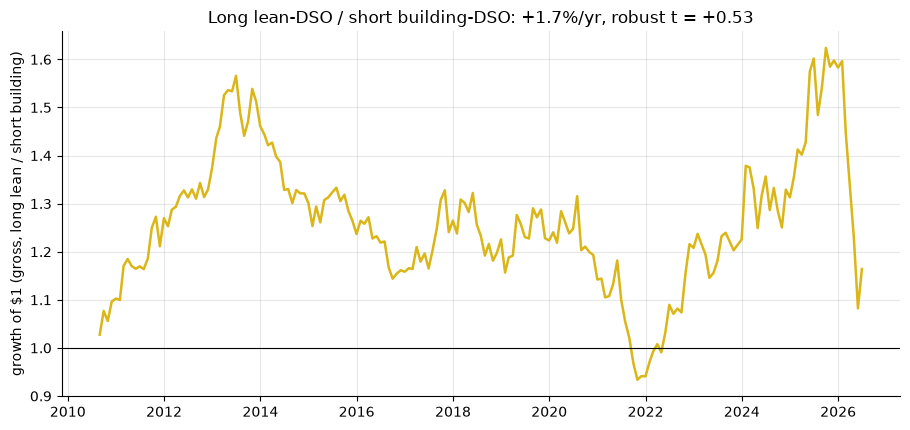

long-short: +1.7%/yr gross, Newey-West t = +0.53 (the bar is 2)


In [3]:
if HAVE_REAL:
    ls = st.calendar_ls(PX, EV, signal_col='dso_score', n_buckets=3, min_names=6, staleness_days=200)
    s = st.calendar_ls_stats(ls)
    ann, tnw = s['ann_pct'], s['t_nw']
    cum = (1+ls['ls']).cumprod()
else:
    ann, tnw = R['ls_ann'], R['ls_t_nw']
    cum = None
fig, ax = plt.subplots(figsize=(9.2, 4.4))
if cum is not None:
    ax.plot(cum.index, cum.values, color=AMBER, lw=1.8); ax.axhline(1.0, c='k', lw=.8)
    ax.set_ylabel('growth of $1 (gross, long lean / short building)')
    ax.set_title(f'Long lean-DSO / short building-DSO: {ann:+.1f}%/yr, robust t = {tnw:+.2f}')
else:
    ax.text(.5,.5,'run with cache for the equity curve',ha='center'); ax.set_axis_off()
plt.tight_layout(); plt.show()
print(f'long-short: {ann:+.1f}%/yr gross, Newey-West t = {tnw:+.2f} (the bar is 2)')

It drifts up a touch — **+1.7%/yr** gross, growing \$1 to only \$1.16 over 191 months — and it's right-signed (lean beats building, as the claim wants). But the robust *t*-statistic is **+0.53**, nowhere near the **2** we require. This is about as close to a flat line as a long-short gets. And it's worse than it looks: a more conservative version of the signal (drop stale filings) is **+5 bps/mo** (*t* = +0.16), and after 2018 the whole thing is **stone dead** (+1 bps/mo, *t* = +0.02).

**The tell:** if the signal really sorted returns, the thirds would form a ladder from building to lean. They don't.

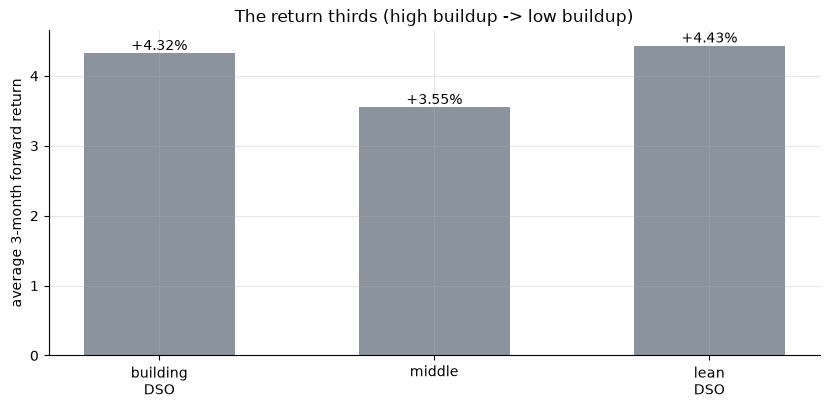

3-month forward return by DSO third (building->lean): ['+4.32%', '+3.55%', '+4.43%']


In [4]:
if HAVE_REAL:
    fr = st.event_drift_frame(PX, EV, horizon=63)
    mono = st.bucket_means(fr, 3)*100
else:
    mono = np.array(R['mono63'])
fig, ax = plt.subplots(figsize=(8.4, 4.2))
ax.bar(['building\nDSO','middle','lean\nDSO'], mono, color=[GREY, GREY, GREY], width=.55)
for i,v in enumerate(mono): ax.annotate(f'{v:+.2f}%',(i,v),ha='center',va='bottom')
ax.set_ylabel('average 3-month forward return')
ax.set_title('The return thirds (high buildup -> low buildup)')
plt.tight_layout(); plt.show()
print('3-month forward return by DSO third (building->lean):', [f'{v:+.2f}%' for v in mono])

No staircase — the thirds come in **+4.32% / +3.55% / +4.43%** (building → lean), a wobble, not a ladder. Over a longer 2-quarter window the ordering actually **flips** (the building third out-returns the lean one). When the sign of your 'edge' depends on the horizon you measure, you don't have an edge — you have noise. Compare that to the *sales* nudge above, which at least pointed the right way. Same signal: a faint truth about the business, nothing about the stock.

## 5 · The verdict

- **Warns on future sales? — Faint.** Lean-DSO names grow next quarter's sales +3.3 points faster than building-DSO names, correctly signed — but correlation just -0.08. The mechanism is real in direction, negligible in size.
- **Signal (returns) — None.** The long-short is right-signed but statistically zero (robust *t* = +0.53), the thirds don't form a ladder (and flip sign at 2 quarters), and it's dead after 2018. No certifiable return predictability on this tape.
- **Tradability — Mirage.** It fails before costs and turns negative after them. Nothing to trade.

> The honest one-liner: *on big liquid names, a rising DSO is a real-but-tiny hint about next quarter's sales and — as far as this tape can tell — no hint at all about the stock.*

## 6 · Going further 🚪

- **Where an edge might still hide.** Not in the *level* of the public ratio, but maybe in the *surprise* — DSO change vs a seasonal expectation — or by conditioning on firms where a receivables build is genuinely unusual (small, opaque, or fast-growing names, not mega-cap blue chips). This study deliberately used large, liquid, heavily-covered names — the *hardest* place for a public red flag to survive.
- **The coverage caveat is real.** Only a subset of names expose a long, cleanly-matched receivables+revenue history on EDGAR; the cross-section is thin early on.
- **Sibling studies:** [231-sloan-accruals](../../231-sloan-accruals/) (total accruals), [522-percent-operating-accruals](../../522-percent-operating-accruals/), [529-inventory-growth](../../529-inventory-growth/) (the *inventory* red flag), and [855-accrual-quality](../../855-accrual-quality/). See [docs/references.md](docs/references.md) for the exact dedup.

*Think the alpha is in the surprise, or in small opaque names, not the level on blue chips? Build it, show a certifiable net spread on the size you'd actually run — then we'll talk.*